<a href="https://colab.research.google.com/github/devisree6330/dc_minip/blob/pranav-kumaravel_me24b049/ViT_For_CIFAR10_Fine_Tuned_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
image = Image.open('car.png').resize((128, 128))
x = np.array(image)
P , C = 16, 3
# patches = x.reshape(x.shape[0]//P, P, x.shape[1]//P, P, C).swapaxes(1,2).reshape(-1,P,P,C)
patches = x.reshape(x.shape[0]//P, P, x.shape[1]//P, P, C).swapaxes(1, 2).reshape(-1, P, P, C)

x_p = np.reshape(patches, (-1,P*P*C))
N = x_p.shape[0]
print('Image shape: {}\nNumber of patches: {} with resolution ({}, {})\nPatches Shape: {}\nFlattened patches shape: {}'.format(x.shape, N, P, P, patches.shape, x_p.shape))

Image shape: (32, 32, 3)
Number of patches: 4 with resolution (16, 16)
Patches Shape: (4, 16, 16, 3)
Flattened patches shape: (4, 768)


In [ ]:
# fig = plt.figure()
# gridspec = fig.add_gridspec(1,2)
# ax1 = fig.add_subplot(gridspec[0])
# ax1.set(title='Image')
# ax1.imshow(x)
# subgrid = gridspec[1].subgridspec(8,8,hspace = -0.8)
# for i in range(8):
#   for j in range(8):
#     num = i*8+j
#     ax = fig.add_subplot(subgridspec[i, j])
#     ax.set(xticks=[], yticks=[])
#     ax.imshow(patches[num])


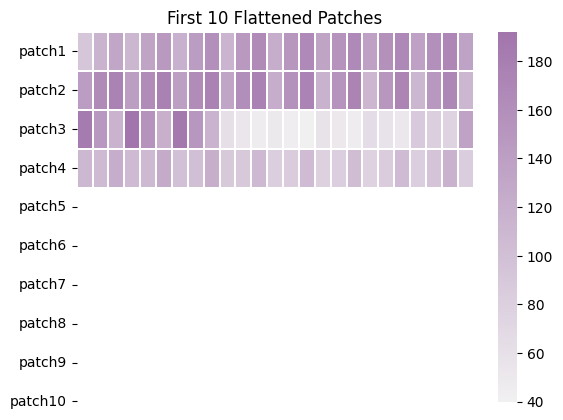

In [ ]:
heatmap = x_p[:10, :25]
yticklabels = ['patch' + str(i+1) for i in range(10)]
plt.title('First 10 Flattened Patches')
ax = sns.heatmap(heatmap,
                 cmap=sns.light_palette('#a275ac', as_cmap=True),
                 xticklabels=False,
                 yticklabels=yticklabels,
                 linewidth=0.01,
                 linecolor='white')


In [ ]:
D = 768
B = 1
x_p = torch.Tensor(x_p)
x_p = x_p[None, ...]
E = nn.Parameter(torch.randn(1,P*P*C,D))
patch_embeddings = torch.matmul(x_p, E)
assert patch_embeddings.shape == (B,N,D)
print(patch_embeddings.shape)

torch.Size([1, 4, 768])


In [ ]:
class_token = nn.Parameter(torch.randn(1,1,D))
patch_embeddings = torch.cat((class_token, patch_embeddings),1)
print(patch_embeddings.shape)
assert patch_embeddings.shape == (B,N+1,D)

torch.Size([1, 5, 768])


In [ ]:
E_pos = nn.Parameter(torch.randn(1, N+1, D))
z0 = patch_embeddings + E_pos
print(z0.shape)
assert z0.shape == (B,N+1,D)

torch.Size([1, 5, 768])


In [ ]:
class SelfAttention(nn.Module):
  def __init__(self, embedding_dim=768, key_dim=64):
    super(SelfAttention, self).__init__()
    self.embedding_dim = embedding_dim
    self.key_dim = key_dim
    self.W = nn.Parameter(torch.randn(embedding_dim, 3*key_dim))

  def forward(self, x):
    key_dim = self.key_dim
    qkv = torch.matmul(x,self.W)
    q = qkv[:,:,:key_dim]
    k = qkv[:,:,key_dim:key_dim*2]
    v = qkv[:,:,key_dim*2:]
    k_T = torch.transpose(k,-2,-1)
    dot_products = torch.matmul(q,k_T)
    scaled_dot_products = dot_products/np.sqrt(key_dim)
    attention_weights = F.softmax(scaled_dot_products, dim=1)
    weighted_values = torch.matmul(attention_weights, v)
    return weighted_values


In [ ]:
D_h = 64
self_attention= SelfAttention(D, D_h)
attention_scores = self_attention(patch_embeddings)
print(attention_scores.shape)
assert attention_scores.shape == (B, N+1, D_h)


torch.Size([1, 5, 64])


In [ ]:
class MultiHeadSelfAttention(nn.Module):
  def __init__(self, embedding_dim=768, num_heads=12):
    super(MultiHeadSelfAttention, self).__init__()
    self.num_heads = num_heads
    self.embedding_dim = embedding_dim
    assert embedding_dim%num_heads == 0
    self.key_dim = embedding_dim//n_head
    self.attention_list = [SelfAttention(embedding_dim, self.key_dim) for _ in range(num_heads)]
    self.multi_head_attention = nn.ModuleList(self.attention_list)
    self.W = nn.Parameter(torch.randn(num_heads*self.key_dim, embedding_dim))

  def forward(self, x):
    attention_scores = [attention(x) for attention in self.multi_head_attention]
    Z = torch.cat(attention_scores, -1)
    attention_score = torch.matmul(Z, self.W)
    return attention_score

In [ ]:
n_head = 12
multi_head_attention = MultiHeadSelfAttention(D, n_head)
attention_score = multi_head_attention(patch_embeddings)
print(attention_score.shape)
assert attention_score.shape == (B,N+1,D)


torch.Size([1, 5, 768])


In [ ]:
class MultiLayerPerception(nn.Module):
  def __init__(self, embedding_dim = 768, hidden_dim=3072):
    super(MultiLayerPerception, self).__init__()
    self.mlp = nn.Sequential(
        nn.Linear(embedding_dim, hidden_dim),
        nn.GELU(),
        nn.Linear(hidden_dim, embedding_dim)
    )
  def forward(self, x):
    x = self.mlp(x)
    return x


In [ ]:
hidden_dim = 3072
mlp = MultiLayerPerception(D, hidden_dim)
output = mlp(patch_embeddings)
assert output.shape == (B,N+1, D)
output.shape


torch.Size([1, 5, 768])

In [ ]:
class TransformerEncoder(nn.Module):
  def __init__(self, embedding_dim=768, num_heads=12, hidden_dim=3072, dropout_prob=0.1):
    super(TransformerEncoder,self).__init__()

    self.MSA = MultiHeadSelfAttention(embedding_dim, num_heads)
    self.MLP = MultiLayerPerception(embedding_dim, hidden_dim)
    self.layer_norm1 = nn.LayerNorm(embedding_dim)
    self.layer_norm2 = nn.LayerNorm(embedding_dim)

    self.dropout1 = nn.Dropout(p=dropout_prob)
    self.dropout2 = nn.Dropout(p=dropout_prob)
    self.dropout3 = nn.Dropout(p=dropout_prob)

  def forward(self, x):
    out_1 = self.dropout1(x)
    out_2 = self.layer_norm1(out_1)
    msa_out = self.MSA(out_2)
    out_3 = self.dropout2(msa_out)
    res_out = x+out_3
    out_4 = self.layer_norm2(res_out)
    mlp_out = self.MLP(out_4)
    out_5 = self.dropout3(mlp_out)
    output = res_out + out_5
    return output


In [ ]:
dropout_prob = 0.1
transformer_encoder = TransformerEncoder(D, n_head, hidden_dim, dropout_prob)
output = transformer_encoder(patch_embeddings)
assert output.shape == (B, N+1, D)
output.shape

torch.Size([1, 5, 768])

In [ ]:
class MLPHead(nn.Module):
  def __init__(self, embedding_dim=768, num_classes=10, fine_tune=False):
    super(MLPHead, self).__init__()
    self.num_classes = num_classes

    if not fine_tune:
      self.mlp_head = nn.Sequential(
          nn.Linear(embedding_dim, 3072),
          nn.Tanh(),
          nn.Linear(3072, num_classes)
      )
    else:
      self.mlp_head = nn.Linear(embedding_dim, num_classes)
  def forward(self, x):
    x = self.mlp_head(x)
    return x


In [ ]:
z_L = output[0][0]
n_class = 10
mlp_head_pretrain = MLPHead(D,n_class)
mlp_head_finetune = MLPHead(D, n_class, fine_tune=True)
output_1 = mlp_head_pretrain(z_L)
output_2 = mlp_head_finetune(z_L)
print(output_1.size(dim=0))
assert output_1.size(dim=0) == n_class
assert output_2.size(dim=0) == n_class

10


In [ ]:
class VisionTransformer(nn.Module):
  def __init__(self, patch_size=16, image_size=224, channel_size=3, num_layers=12,
               embedding_dim=768, num_heads=12, hidden_dim=3072,
               dropout_prob=0.1, num_classes=10, pretrain=True):
    super(VisionTransformer, self).__init__()
    self.patch_size = patch_size
    self.channel_size = channel_size
    self.num_layers = num_layers
    self.embedding_dim = embedding_dim
    self.num_heads = num_heads
    self.hidden_dim = hidden_dim
    self.dropout_prob = dropout_prob
    self.num_classes = num_classes

    self.num_patches = int((image_size**2)/(patch_size**2))
    self.W = nn.Parameter(torch.randn(patch_size*patch_size*channel_size, embedding_dim))
    self.pos_embedding = nn.Parameter(torch.randn(self.num_patches+1, embedding_dim))
    self.class_token = nn.Parameter(torch.rand(1,D))
    transformer_encoder_list = [
        TransformerEncoder(embedding_dim, num_heads, hidden_dim, dropout_prob)
        for _ in range(num_layers)
    ]
    self.transformer_encoder_layers = nn.Sequential(*transformer_encoder_list)
    self.mlp_head = MLPHead(embedding_dim, num_classes)

  def forward(self, x):
    P, C = self.patch_size, self.channel_size
    patches = x.unfold(1,C,C).unfold(2,P,P).unfold(3,P,P)
    patches = patches.contiguous().view(patches.size(0), -1,C*P*P).float()
    patch_embeddings = torch.matmul(patches, self.W)
    batch_size = patch_embeddings.shape[0]
    patch_embeddings = torch.cat((self.class_token.repeat(batch_size,1,1), patch_embeddings),1)
    patch_embeddings = patch_embeddings+self.pos_embedding
    transformer_encoder_output = self.transformer_encoder_layers(patch_embeddings)
    output_class_token = transformer_encoder_output[:,0]
    y = self.mlp_head(output_class_token)
    return y



In [ ]:
image_size = 224; channel_size = 3
n_class = 10
dropout_prob = 0.1
n_layer = 12; embedding_dim = 768; n_head = 12; hidden_dim=3072
image = Image.open('car.png').resize((image_size, image_size))
X = T.PILToTensor()(image)
X = X[None, ...]
patch_size=16
vision_transformer = VisionTransformer(patch_size, image_size, channel_size, n_layer, embedding_dim, n_head, hidden_dim,
                                       dropout_prob, n_class)
vit_output = vision_transformer(X)
assert vit_output.size(dim=1) == n_class
print(vit_output.shape)
probablities = F.softmax(vit_output[0], dim=0)
print(torch.sum(probablities))


torch.Size([1, 10])
tensor(1., grad_fn=<SumBackward0>)


Traning the model

In [ ]:
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.models as models
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

In [ ]:
image_size = 224
transform = T.Compose([T.Resize(image_size), T.ToTensor()])
torchvision.datasets.CIFAR10.url = 'http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
trainset = datasets.CIFAR10(root='data', train=True, download=True, transform=transform)
testset = datasets.CIFAR10(root='data', train=False, download=True, transform=transform)
classes = trainset.classes
trainset = torch.utils.data.Subset(trainset, list(range(5000)))
testset = torch.utils.data.Subset(testset, list(range(1000)))
print(classes)

100%|██████████| 170M/170M [00:07<00:00, 24.0MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
batch_size = 16
valid_size = 0.2
train_size = len(trainset)
indices = list(range(train_size))
np.random.shuffle(indices)
split = int(np.floor(valid_size*train_size))
train_idx, valid_idx = indices[split:], indices[:split]
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)
train_loader = DataLoader(trainset, batch_size=batch_size, sampler=train_sampler)
valid_loader = DataLoader(trainset, batch_size=batch_size, sampler=valid_sampler)
test_loader = DataLoader(testset, batch_size=batch_size)


In [ ]:
train_labels = [labels for i, (image, labels) in enumerate(train_loader)]
train_labels = torch.cat((train_labels), 0)
train_labels_count = train_labels.unique(return_counts=True)

print('The number of samples per classes in training dataset:\n')
for label, count in zip(train_labels_count[0], train_labels_count[1]):
    print('\t {}: {}'.format(label, count))

test_labels = [labels for i, (images, labels) in enumerate(test_loader)]
test_labels = torch.cat((test_labels), 0)
test_labels_count = test_labels.unique(return_counts=True)
print('\nThe number of samples per classes in test dataset:\n')
for label, count in zip(test_labels_count[0], test_labels_count[1]):
    print('\t {}: {}'.format(label, count))

The number of samples per classes in training dataset:

	 0: 409
	 1: 367
	 2: 415
	 3: 398
	 4: 407
	 5: 392
	 6: 418
	 7: 380
	 8: 415
	 9: 399

The number of samples per classes in test dataset:

	 0: 103
	 1: 89
	 2: 100
	 3: 103
	 4: 90
	 5: 86
	 6: 112
	 7: 102
	 8: 106
	 9: 109


In [ ]:
vision_transformer = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

vision_transformer

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:02<00:00, 166MB/s]


VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
vision_transformer.heads


Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)

In [ ]:
vision_transformer.heads = nn.Linear(in_features=768, out_features=len(classes), bias=True)

for p in vision_transformer.parameters():
  p.requires_grad = False

for p in vision_transformer.heads.parameters():
  p.requires_grad = True


In [ ]:
for layer_name, p in vision_transformer.named_parameters():
  print('Layer Name: {}, Frozen: {}\n'.format(layer_name, not p.requires_grad))


Layer Name: class_token, Frozen: True

Layer Name: conv_proj.weight, Frozen: True

Layer Name: conv_proj.bias, Frozen: True

Layer Name: encoder.pos_embedding, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.ln_1.weight, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.ln_1.bias, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.self_attention.in_proj_weight, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.self_attention.in_proj_bias, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.self_attention.out_proj.weight, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.self_attention.out_proj.bias, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.ln_2.weight, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.ln_2.bias, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.mlp.0.weight, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.mlp.0.bias, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.mlp.3.weight, Fro

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, vision_transformer.parameters()), lr=0.0001)


In [ ]:
train_on_gpu = torch.cuda.is_available()
train_on_gpu

True

In [ ]:
import os
model_path = 'vit.pth'
if os.path.exists(model_path):
  vision_transformer.load_state_dict(torch.load(model_path))


In [ ]:
n_epoch = 5
n_step = 100
train_loss_list, valid_loss_list = [], []
if train_on_gpu:
  vision_transformer.to('cuda')

vision_transformer.train()
for e in range(n_epoch):
  train_loss = 0.0
  valid_loss = 0.0

  for i, (images, targets) in enumerate(train_loader):

    if train_on_gpu:
      images, targets = images.to('cuda'), targets.to('cuda')
    optimizer.zero_grad()
    outputs = vision_transformer(images)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
    train_loss+=loss.item()
    if i%n_step == 0:
      torch.save(vision_transformer.state_dict(), model_path)

  vision_transformer.eval()
  for images, targets in valid_loader:
    if train_on_gpu:
      images = images.to('cuda')
      targets = targets.to('cuda')
    with torch.no_grad():
      outputs = vision_transformer(images)
      loss = criterion(outputs, targets)
      valid_loss +=loss.item()
  vision_transformer.train()
  train_loss = train_loss /len(train_loader)
  valid_loss = valid_loss /len(valid_loader)
  train_loss_list.append(train_loss)
  valid_loss_list.append(valid_loss)
  print('Epoch: {} \t Training Loss: {:.6f} \t Validation Loss: {:.6f}'
                  .format( (e+1), train_loss, valid_loss))

Epoch: 1 	 Training Loss: 1.705669 	 Validation Loss: 1.196437
Epoch: 2 	 Training Loss: 0.945697 	 Validation Loss: 0.786505
Epoch: 3 	 Training Loss: 0.676716 	 Validation Loss: 0.613170
Epoch: 4 	 Training Loss: 0.552983 	 Validation Loss: 0.526726
Epoch: 5 	 Training Loss: 0.481643 	 Validation Loss: 0.474893


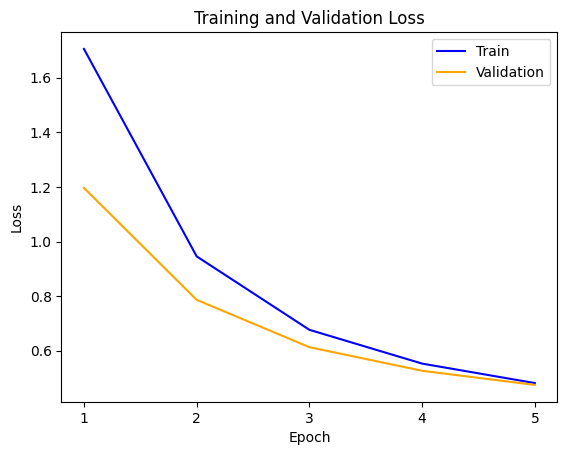

In [ ]:
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

x = list(range(1, n_epoch + 1))
plt.plot(x, train_loss_list, color ="blue", label='Train')
plt.plot(x, valid_loss_list, color="orange", label='Validation')
plt.legend(loc="upper right")
plt.xticks(x)

plt.show()

In [ ]:
vision_transformer.eval()

test_loss = 0.0
accuracy = 0

n_class = len(classes)
class_correct = np.zeros(n_class)
class_total = np.zeros(n_class)
vision_transformer = vision_transformer.to('cpu')
for images, targets in test_loader:
    outputs = vision_transformer(images)
    loss = criterion(outputs, targets)
    test_loss += loss.item()
    preds = torch.argmax(F.softmax(outputs, dim=1), dim=1)
    correct_preds = (preds == targets).type(torch.FloatTensor)
    accuracy += torch.mean(correct_preds).item() * 100
    for c in range(n_class):

        class_total[c] += (targets == c).sum()
        class_correct[c] += ((correct_preds) * (targets == c)).sum()

accuracy = accuracy / len(test_loader)
test_loss = test_loss / len(test_loader)
print('Test Loss: {:.6f}'.format(test_loss))

Test Loss: 0.458080


In [ ]:
class_accuracy = class_correct / class_total

print('Test Accuracy of Classes')
print()

for c in range(n_class):
    print('{}\t: {}% \t ({}/{})'.format(classes[c],
                                int(class_accuracy[c] * 100), int(class_correct[c]), int(class_total[c])) )

print()
print('Test Accuracy of Dataset: \t {}% \t ({}/{})'.format(int(accuracy),
                                                           int(np.sum(class_correct)), int(np.sum(class_total)) ))

Test Accuracy of Classes

airplane	: 86% 	 (89/103)
automobile	: 89% 	 (80/89)
bird	: 83% 	 (83/100)
cat	: 80% 	 (83/103)
deer	: 86% 	 (78/90)
dog	: 86% 	 (74/86)
frog	: 90% 	 (101/112)
horse	: 87% 	 (89/102)
ship	: 96% 	 (102/106)
truck	: 88% 	 (96/109)

Test Accuracy of Dataset: 	 87% 	 (875/1000)
